In [62]:
import pandas as pd
df = pd.read_csv('c:/data/iris/iris.csv')
df


,SepalLength,SepalWidth,PetalLength,PetalWidth,target,Species
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2
146,6.3,2.5,5.0,1.9,virginica,2
147,6.5,3.0,5.2,2.0,virginica,2
148,6.2,3.4,5.4,2.3,virginica,2


In [28]:
df.columns

Index(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'target',
       'Species'],
      dtype='object')

In [29]:
# 품종을 기준으로 한 평균값들
df[['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']].groupby('Species').mean()

,SepalLength,SepalWidth,PetalLength,PetalWidth
Species,,,,
0,5.006,3.418,1.464,0.244
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


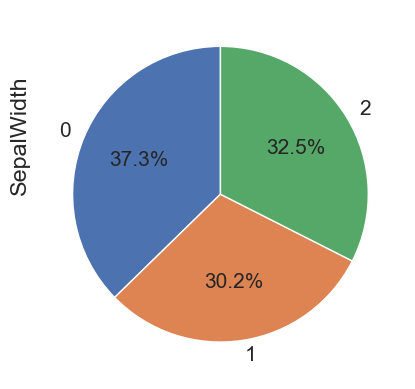

In [48]:
# 파이차트
import matplotlib.pyplot as plt
sums_by_species = df.groupby('Species').sum()
var = 'SepalWidth'
sums_by_species[var].plot(kind='pie', fontsize=15, autopct='%1.1f%%', startangle=90)
plt.ylabel(var, horizontalalignment='left')
plt.show()

In [61]:
# 품종별 변수 합계
sums_by_species = df.groupby('Species').sum()
print(sums_by_species)

         SepalLength  SepalWidth  PetalLength  PetalWidth  \
Species                                                     
0              250.3       170.9         73.2        12.2   
1              296.8       138.5        213.0        66.3   
2              329.4       148.7        277.6       101.3   

                                                    target  
Species                                                     
0        setosasetosasetosasetosasetosasetosasetosaseto...  
1        versicolorversicolorversicolorversicolorversic...  
2        virginicavirginicavirginicavirginicavirginicav...  


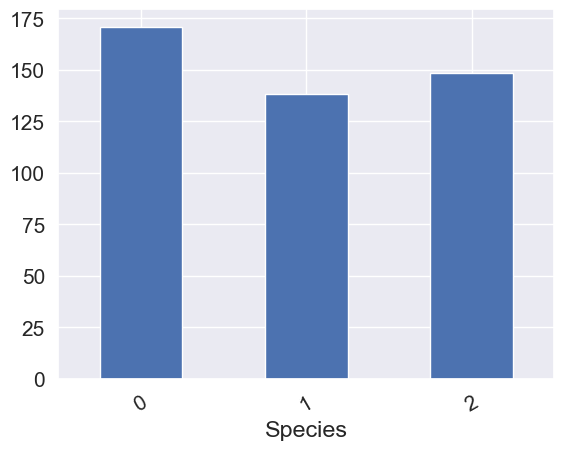

In [32]:
# 꽃받침 너비 기준 막대그래프
var = 'SepalWidth'
sums_by_species[var].plot(kind='bar', fontsize=15, rot=30)
plt.show()

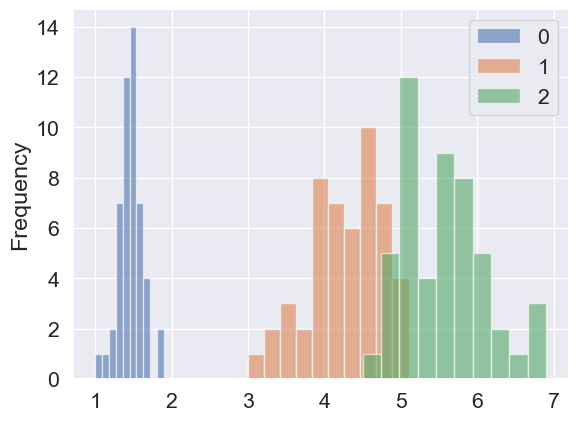

In [49]:
# 품종별 꽃잎 길이
for spec in df['Species'].unique():
    subdf = df[df['Species'] == spec]
    subdf['PetalLength'].plot(kind='hist', alpha=0.6, label=spec)
plt.legend(loc='upper right')

In [34]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

Text(0.5, 1.0, 'iris\n (0: setosa, 1: versicolor, 2: virginica)')

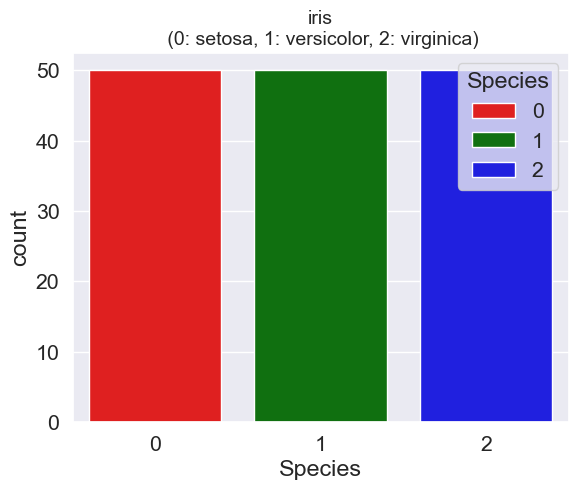

In [35]:
import seaborn as sns
colors = ['red','green','blue']
sns.countplot(x='Species', data=df, palette=colors, hue='Species')
plt.title('iris\n (0: setosa, 1: versicolor, 2: virginica)', fontsize=14)

In [36]:
cols = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
X = df[cols]
y = df['Species']

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print('학습용:',model.score(X_train, y_train))
print('검증용:',model.score(X_test, y_test))

학습용: 0.9666666666666667
검증용: 1.0


In [50]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
pred = model.predict(X_test)
cm = confusion_matrix(y_test, pred)
print(cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [52]:
# 정오분류표
df_cm=pd.DataFrame(cm, index=[0,1,2], columns=[0,1,2])
print(df_cm)
df_cm

    0   1   2
0  10   0   0
1   0  10   0
2   0   0  10


,0,1,2
0,10,0,0
1,0,10,0
2,0,0,10


<Axes: title={'center': 'Confusion Matrix'}>

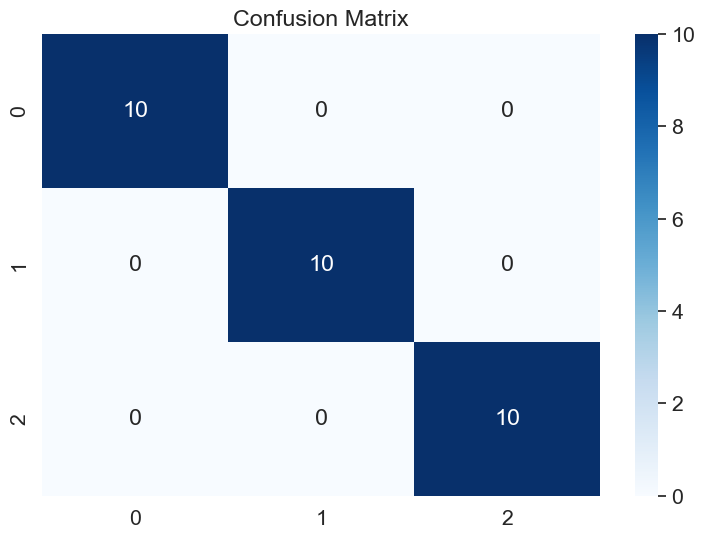

In [40]:
# 히트맵
sns.set_theme(font_scale=1.4)
plt.figure(figsize=(9,6))
plt.title('Confusion Matrix')
sns.heatmap(df_cm, annot=True, cmap='Blues')

In [41]:
# 새로운 값 입력 분류테스트
flowers = ['setosa', 'versicolor', 'virginica']
X_new = [[7,3,5,1.4]]
pred = model.predict(X_new)
flowers[pred[0]]

C:\python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'versicolor'

In [42]:
# 모델 저장
import joblib
joblib.dump(model, 'c:/data/iris/iris_logit.model')

['c:/data/iris/iris_logit.model']